In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import json
from glob import glob
import pickle
from tqdm import tqdm
import time

In [2]:
from his_pipeline import Pathological

In [3]:
pipeline = Pathological(config_path='config/config_pipeline.json')

Load Model FastFlow
Load Model Palette


# pipeline

dict_keys(['image', 'anomaly_map', 'pred_label', 'background', 'background_label', 'mask', 'restore'])


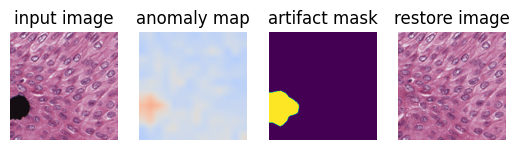

The image is detected as an artifact:  True


In [4]:
colormap = 'coolwarm'
cmap = plt.get_cmap(colormap)
image_path = './data/sample_patch/artifact_1.png'
result = pipeline.pipeline(image_path=image_path)
print(result.keys())
plt.figure()
plt.subplot(141), plt.imshow(result['image']), plt.title('input image'), plt.axis('off')
plt.subplot(142), plt.imshow(result['anomaly_map'], cmap=colormap, vmin=0, vmax=1), plt.title('anomaly map'), plt.axis('off')
plt.subplot(143), plt.imshow(result['mask']), plt.title('artifact mask'), plt.axis('off')
plt.subplot(144), plt.imshow(result['restore']), plt.title('restore image'), plt.axis('off')
plt.show()
print('The image is detected as an artifact: ', result['pred_label'])

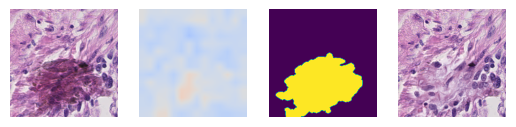

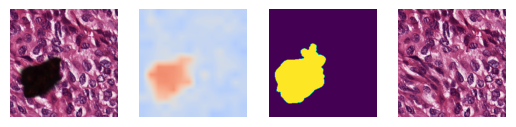

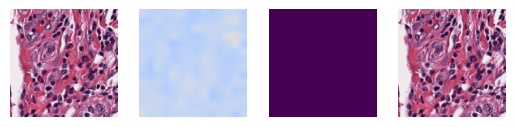

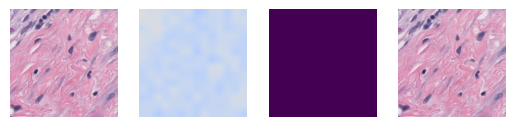

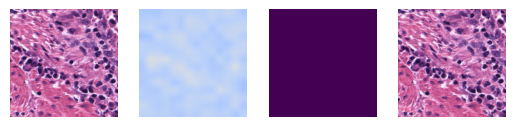

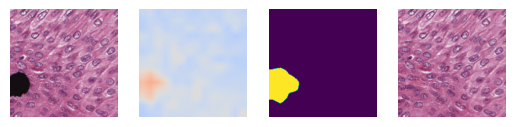

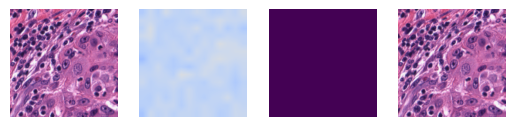

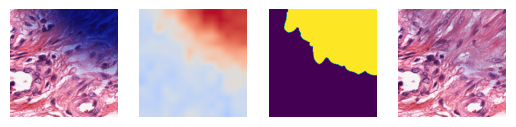

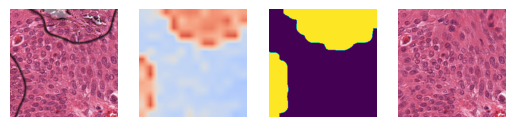

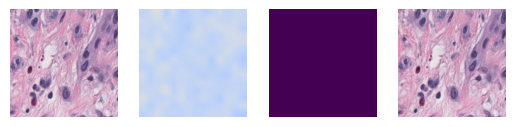

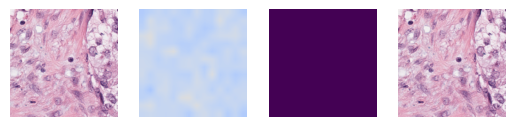

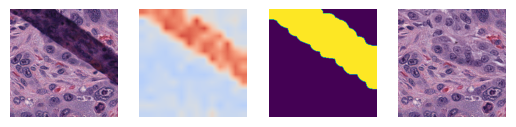

In [8]:
colormap = 'coolwarm'
cmap = plt.get_cmap(colormap)
imgs = glob('./data/sample_patch/*.png')
for image_path in imgs:
    result = pipeline.pipeline(image_path=image_path)
    plt.figure()
    plt.subplot(141), plt.imshow(result['image']), plt.axis('off')
    plt.subplot(142), plt.imshow(result['anomaly_map'], cmap=colormap, vmin=0, vmax=1), plt.axis('off')
    plt.subplot(143), plt.imshow(result['mask']), plt.axis('off')
    plt.subplot(144), plt.imshow(result['restore']), plt.axis('off')
    plt.show()

# detect

dict_keys(['image', 'anomaly_map', 'pred_label'])


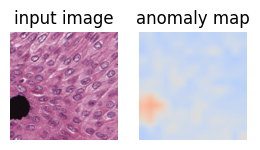

In [5]:
colormap = 'coolwarm'
cmap = plt.get_cmap(colormap)
image_path = './data/sample_patch/artifact_1.png'
result = pipeline.detect(image_path=image_path)
print(result.keys())
plt.figure()
plt.subplot(141), plt.imshow(result['image']), plt.title('input image'), plt.axis('off')
plt.subplot(142), plt.imshow(result['anomaly_map'], cmap=colormap, vmin=0, vmax=1), plt.title('anomaly map'), plt.axis('off')
plt.show()

# locate

dict_keys(['image', 'anomaly_map', 'pred_label', 'mask'])


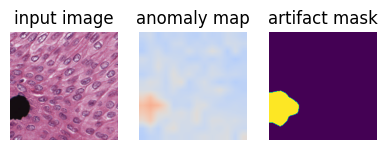

In [6]:
colormap = 'coolwarm'
cmap = plt.get_cmap(colormap)
image_path = './data/sample_patch/artifact_1.png'
result = pipeline.detect(image_path=image_path)
result = pipeline.locate(image=result['image'], anomaly_map=result['anomaly_map'])
print(result.keys())
plt.figure()
plt.subplot(141), plt.imshow(result['image']), plt.title('input image'), plt.axis('off')
plt.subplot(142), plt.imshow(result['anomaly_map'], cmap=colormap, vmin=0, vmax=1), plt.title('anomaly map'), plt.axis('off')
plt.subplot(143), plt.imshow(result['mask']), plt.title('artifact mask'), plt.axis('off')
plt.show()

# restore

dict_keys(['image', 'anomaly_map', 'pred_label', 'mask'])
dict_keys(['image', 'mask', 'restore'])


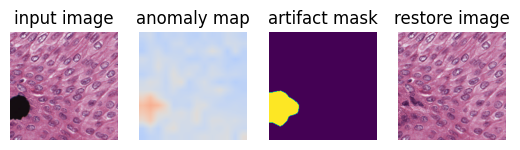

In [7]:
colormap = 'coolwarm'
cmap = plt.get_cmap(colormap)
image_path = './data/sample_patch/artifact_1.png'
result = pipeline.detect(image_path=image_path)
result = pipeline.locate(image=result['image'], anomaly_map=result['anomaly_map'])
result_restore = pipeline.restore(image=result['image'], mask=result['mask'])
print(result.keys())
print(result_restore.keys())
plt.figure()
plt.subplot(141), plt.imshow(result['image']), plt.title('input image'), plt.axis('off')
plt.subplot(142), plt.imshow(result['anomaly_map'], cmap=colormap, vmin=0, vmax=1), plt.title('anomaly map'), plt.axis('off')
plt.subplot(143), plt.imshow(result['mask']), plt.title('artifact mask'), plt.axis('off')
plt.subplot(144), plt.imshow(result_restore['restore']), plt.title('restore image'), plt.axis('off')
plt.show()